# Mental Health Text Dataset — Statistical Analysis

Analysis of social-media posts annotated with mental-health tags.

**Configuration** — change `DATASET_FILENAME` below to point to a different CSV file.
All generated plots are saved into the `artifacts/` directory.

In [53]:
# ============================================================
# CONFIGURATION — change these values to analyze another dataset
# ============================================================
DATASET_FILENAME = 'data.csv'   # path to the CSV file
CSV_SEP = ';'                    # CSV separator
CSV_ENCODING = 'utf-8'
TEXT_COL = 'text'
TAG_COL = 'tag'
ARTIFACTS_DIR = 'artifacts'      # folder where all plots will be saved

# Whether to downsample the majority class for visualization purposes
DOWNSAMPLE_MAJORITY = True
MAJORITY_CAP_MULTIPLIER = 3      # cap majority class at N x second-largest class
RANDOM_STATE = 42

In [54]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Make sure the artifacts directory exists
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Stem (filename without extension) used to prefix artifact filenames so that
# running this notebook on different datasets does not overwrite each other's outputs.
DATASET_STEM = os.path.splitext(os.path.basename(DATASET_FILENAME))[0]

def artifact_path(name: str) -> str:
    """Build a path inside the artifacts directory, prefixed with the dataset stem."""
    return os.path.join(ARTIFACTS_DIR, f'{DATASET_STEM}__{name}')

print(f'Dataset:   {DATASET_FILENAME}')
print(f'Artifacts: {os.path.abspath(ARTIFACTS_DIR)}')

Dataset:   data.csv
Artifacts: /Users/ilyasar004/Documents/nlp/project/artifacts


---
## 1. Load Data

In [55]:
df = pd.read_csv(DATASET_FILENAME, sep=CSV_SEP, encoding=CSV_ENCODING)
df = df[[TEXT_COL, TAG_COL]].copy()
df = df.dropna().reset_index(drop=True)

print(f'Shape (raw): {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
print('Raw tag distribution:')
print(df[TAG_COL].value_counts().to_string())

if DOWNSAMPLE_MAJORITY and df[TAG_COL].nunique() > 1:
    counts = df[TAG_COL].value_counts()
    second_largest = counts.iloc[1]
    cap = second_largest * MAJORITY_CAP_MULTIPLIER
    majority_class = counts.index[0]
    if counts.iloc[0] > cap:
        df_majority = df[df[TAG_COL] == majority_class].sample(n=cap, random_state=RANDOM_STATE)
        df_rest = df[df[TAG_COL] != majority_class]
        df = pd.concat([df_majority, df_rest]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        print(f'\nAfter downsampling "{majority_class}" to {cap} samples:')
        print(df[TAG_COL].value_counts().to_string())

print(f'\nFinal shape: {df.shape}')
df.head(3)

Shape (raw): (66459, 2)
Columns: ['text', 'tag']

Raw tag distribution:
tag
депрессия                   37639
тревожное р-во              10069
ОКР                          5393
ПРЛ                          5219
БАР                          2961
тревожное р-во/невроз        2217
шизофрения                   2055
паранойя                      905
тревожное р-во/депрессия        1

After downsampling "депрессия" to 30207 samples:
tag
депрессия                   30207
тревожное р-во              10069
ОКР                          5393
ПРЛ                          5219
БАР                          2961
тревожное р-во/невроз        2217
шизофрения                   2055
паранойя                      905
тревожное р-во/депрессия        1

Final shape: (59027, 2)


,text,tag
0,Человек мне пишет какие-то агрессивные и неаде...,тревожное р-во
1,Ну так-то да... а на деле вон как вышло. Иначе...,ПРЛ
2,"Вижу, что Вам очень нелегко. Столько всего нав...",депрессия


---
## 2. Tag Distribution Statistics

In [56]:
tag_counts = df[TAG_COL].value_counts()
tag_pct = df[TAG_COL].value_counts(normalize=True) * 100

tag_stats = pd.DataFrame({
    'count': tag_counts,
    'percentage': tag_pct.round(2)
})

print('=== Tag Distribution ===')
print(tag_stats.to_string())
print(f'\nTotal samples: {len(df)}')
print(f'Number of unique tags: {df[TAG_COL].nunique()}')

# Save table to artifacts as well
tag_stats.to_csv(artifact_path('tag_distribution.csv'))
print(f'\nSaved table to {artifact_path("tag_distribution.csv")}')

=== Tag Distribution ===
                          count  percentage
tag                                        
депрессия                 30207       51.17
тревожное р-во            10069       17.06
ОКР                        5393        9.14
ПРЛ                        5219        8.84
БАР                        2961        5.02
тревожное р-во/невроз      2217        3.76
шизофрения                 2055        3.48
паранойя                    905        1.53
тревожное р-во/депрессия      1        0.00

Total samples: 59027
Number of unique tags: 9

Saved table to artifacts/data__tag_distribution.csv


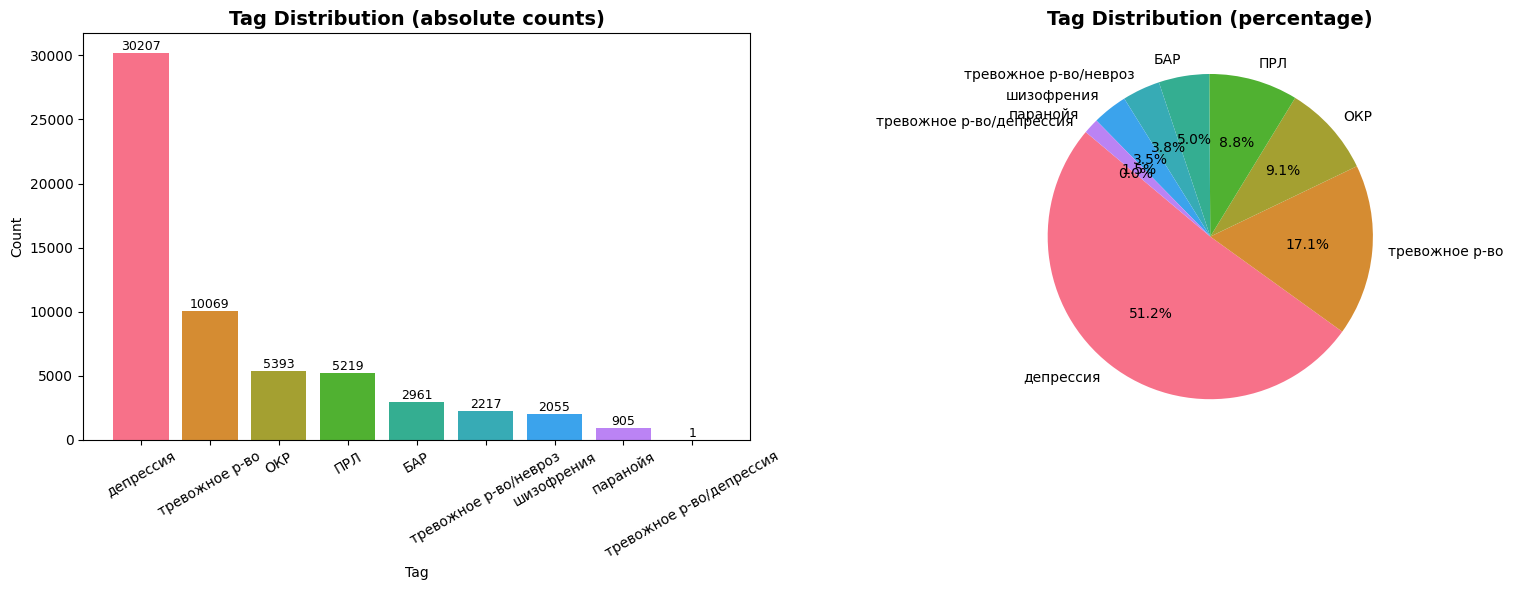

Chart saved to artifacts/data__tag_distribution.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('husl', len(tag_counts))
axes[0].bar(tag_counts.index.astype(str), tag_counts.values, color=colors)
axes[0].set_title('Tag Distribution (absolute counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tag')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (tag, count) in enumerate(tag_counts.items()):
    axes[0].text(i, count, str(count), ha='center', va='bottom', fontsize=9)

axes[1].pie(
    tag_counts.values,
    labels=tag_counts.index.astype(str),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Tag Distribution (percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
out = artifact_path('tag_distribution.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

---
## 3. Text Length Statistics

In [58]:
df['text_len'] = df[TEXT_COL].astype(str).apply(len)
df['word_count'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print('=== Text Length Statistics (characters) ===')
print(df['text_len'].describe().round(1))

print('\n=== Word Count Statistics ===')
print(df['word_count'].describe().round(1))

=== Text Length Statistics (characters) ===
count    59027.0
mean       282.6
std        544.0
min          1.0
25%         63.0
50%        139.0
75%        303.0
max      32767.0
Name: text_len, dtype: float64

=== Word Count Statistics ===
count    59027.0
mean        43.8
std         83.4
min          1.0
25%         10.0
50%         22.0
75%         47.0
max       5668.0
Name: word_count, dtype: float64


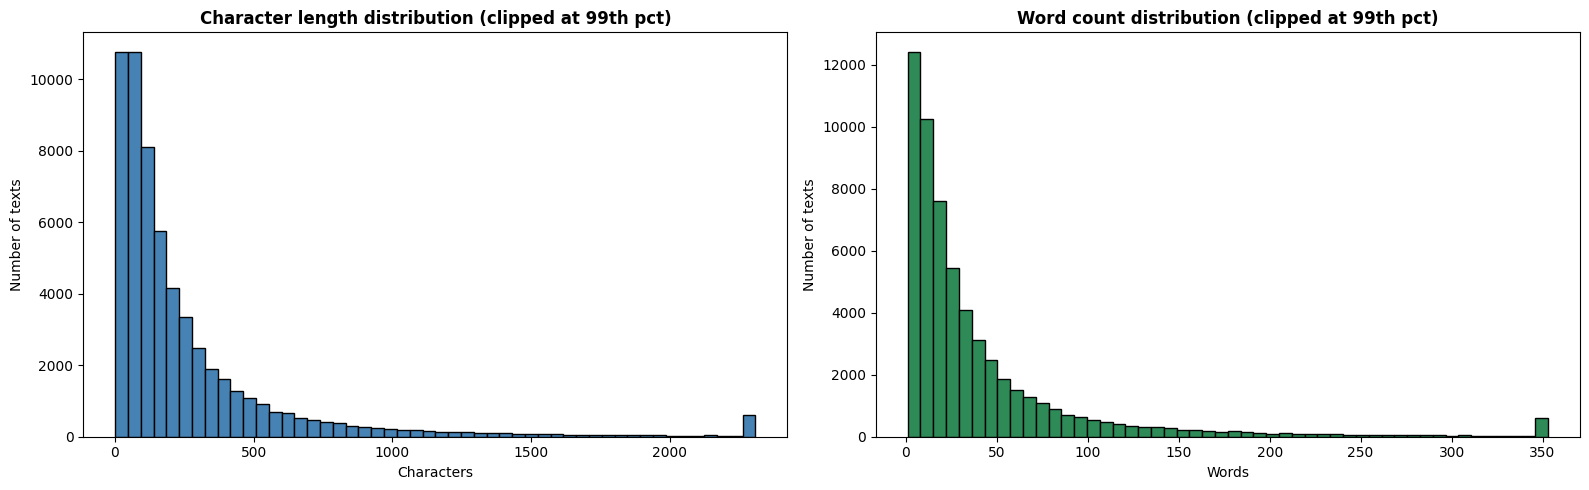

Chart saved to artifacts/data__text_length_distribution.png


In [59]:
# Histograms of character length and word count
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['text_len'].clip(upper=df['text_len'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Character length distribution (clipped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Number of texts')

axes[1].hist(df['word_count'].clip(upper=df['word_count'].quantile(0.99)),
             bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Word count distribution (clipped at 99th pct)', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Number of texts')

plt.tight_layout()
out = artifact_path('text_length_distribution.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

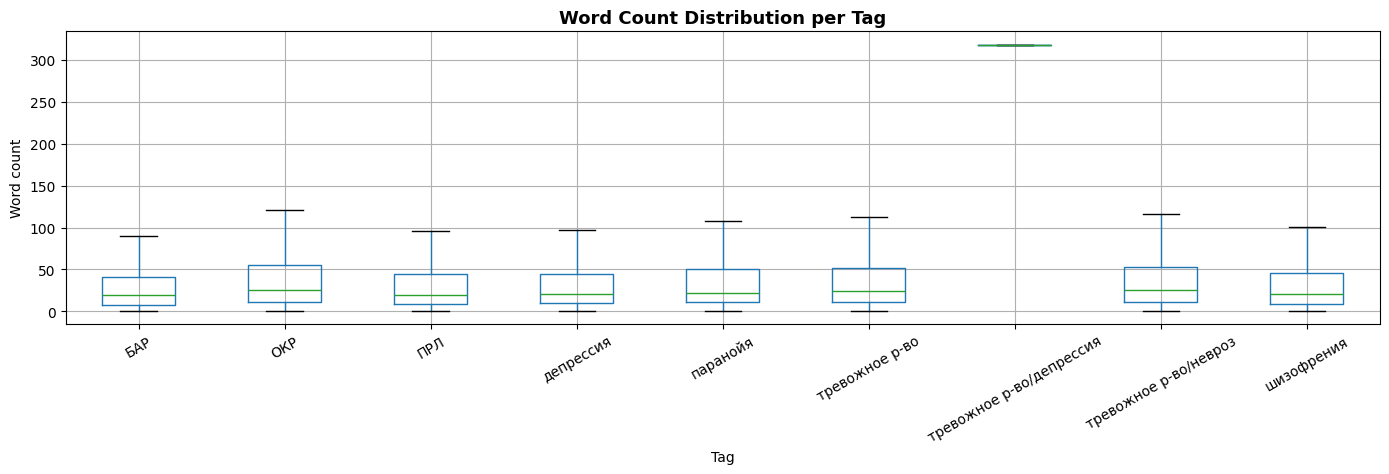

Chart saved to artifacts/data__word_count_by_tag.png


In [60]:
# Word count distribution per tag (boxplot)
fig, ax = plt.subplots(figsize=(14, 5))
df.boxplot(column='word_count', by=TAG_COL, ax=ax, showfliers=False)
ax.set_title('Word Count Distribution per Tag', fontsize=13, fontweight='bold')
ax.set_xlabel('Tag')
ax.set_ylabel('Word count')
plt.suptitle('')
plt.xticks(rotation=30)
plt.tight_layout()
out = artifact_path('word_count_by_tag.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

In [61]:
# Mean / median text length per tag
per_tag_len = df.groupby(TAG_COL)[['text_len', 'word_count']].agg(['mean', 'median', 'std']).round(1)
print('=== Length statistics per tag ===')
print(per_tag_len.to_string())
per_tag_len.to_csv(artifact_path('length_per_tag.csv'))
print(f'\nSaved table to {artifact_path("length_per_tag.csv")}')

=== Length statistics per tag ===
                         text_len                word_count             
                             mean  median    std       mean median   std
tag                                                                     
БАР                         257.1   118.0  579.5       39.8   19.0  90.6
ОКР                         311.2   164.0  551.6       48.3   25.0  85.1
ПРЛ                         269.2   128.0  573.7       41.6   20.0  83.1
депрессия                   275.7   134.0  563.8       42.7   21.0  86.6
паранойя                    289.4   140.0  484.4       45.9   22.0  78.6
тревожное р-во              299.7   153.0  458.3       46.0   24.0  69.4
тревожное р-во/депрессия   1965.0  1965.0    NaN      318.0  318.0   NaN
тревожное р-во/невроз       311.6   159.0  558.9       49.0   25.0  88.5
шизофрения                  261.5   131.0  482.1       41.3   21.0  78.3

Saved table to artifacts/data__length_per_tag.csv


---
## 4. Duplicates & Empty Texts

In [62]:
n_total = len(df)
n_dup_text = df[TEXT_COL].duplicated().sum()
n_empty = (df[TEXT_COL].astype(str).str.strip() == '').sum()
n_short = (df['word_count'] < 5).sum()

print(f'Total samples:                   {n_total}')
print(f'Duplicate texts:                 {n_dup_text} ({n_dup_text / n_total * 100:.2f}%)')
print(f'Empty texts:                     {n_empty}')
print(f'Very short texts (< 5 words):    {n_short} ({n_short / n_total * 100:.2f}%)')

Total samples:                   59027
Duplicate texts:                 1069 (1.81%)
Empty texts:                     0
Very short texts (< 5 words):    5269 (8.93%)


---
## 5. Most Frequent Words per Tag

Top-10 most frequent words for each tag after removing Russian stop-words.
Words are counted on the raw (non-lemmatised) lower-cased text so the result
is easy to read.

In [63]:
import re
from collections import Counter

try:
    import nltk
    from nltk.corpus import stopwords as _sw
    nltk.download('stopwords', quiet=True)
    RU_STOPWORDS = set(_sw.words('russian'))
except Exception:
    RU_STOPWORDS = set()

DOMAIN_STOPWORDS = {
    'психолог', 'психотерапевт', 'специалист', 'терапия', 'терапевт',
    'психотерапия', 'психиатр', 'психиатрия',
    'человек', 'люди', 'жизнь', 'время', 'ситуация', 'проблема',
    'помощь', 'помочь', 'работа', 'работать',
    'автор', 'пост', 'форум', 'комментарий', 'тема',
    'вообще', 'просто', 'конечно', 'наверное', 'наверно',
    'кстати', 'вроде', 'типа', 'короче',
    'это', 'очень'
}
RU_STOPWORDS |= DOMAIN_STOPWORDS

_CLEAN_RE = re.compile(r'[^а-яёА-ЯЁa-zA-Z\s]')
_WS_RE    = re.compile(r'\s+')

TOP_N = 10   # number of top words to show per tag

def tokenize(text: str):
    """Lower-case, strip punctuation/digits, split into tokens, remove stop-words."""
    text = _CLEAN_RE.sub(' ', str(text).lower())
    text = _WS_RE.sub(' ', text).strip()
    return [t for t in text.split() if t not in RU_STOPWORDS and len(t) > 2]

print(f'=== Top-{TOP_N} most frequent words per tag ===')
print()

tag_word_rows = []

for tag, group in df.groupby(TAG_COL):
    counter = Counter()
    for text in group[TEXT_COL]:
        counter.update(tokenize(text))
    top = counter.most_common(TOP_N)
    print(f'  [{tag}]')
    for rank, (word, freq) in enumerate(top, 1):
        print(f'    {rank:>2}. {word:<25s}  {freq:>6,}')
        tag_word_rows.append({'tag': tag, 'rank': rank, 'word': word, 'freq': freq})
    print()

top_words_df = pd.DataFrame(tag_word_rows)
out = artifact_path('top_words_per_tag.csv')
top_words_df.to_csv(out, index=False)
print(f'Saved to {out}')

=== Top-10 most frequent words per tag ===

  [БАР]
     1. бар                           321
     2. лет                           221
     3. могу                          216
     4. всё                           210
     5. ещё                           203
     6. нужно                         178
     7. спасибо                       160
     8. знаю                          160
     9. хочу                          152
    10. жизни                         147

  [ОКР]
     1. окр                           607
     2. мысли                         564
     3. всё                           506
     4. нужно                         463
     5. могу                          430
     6. именно                        391
     7. жизни                         374
     8. страх                         357
     9. почему                        351
    10. ещё                           350

  [ПРЛ]
     1. прл                           929
     2. писал                         565
     3

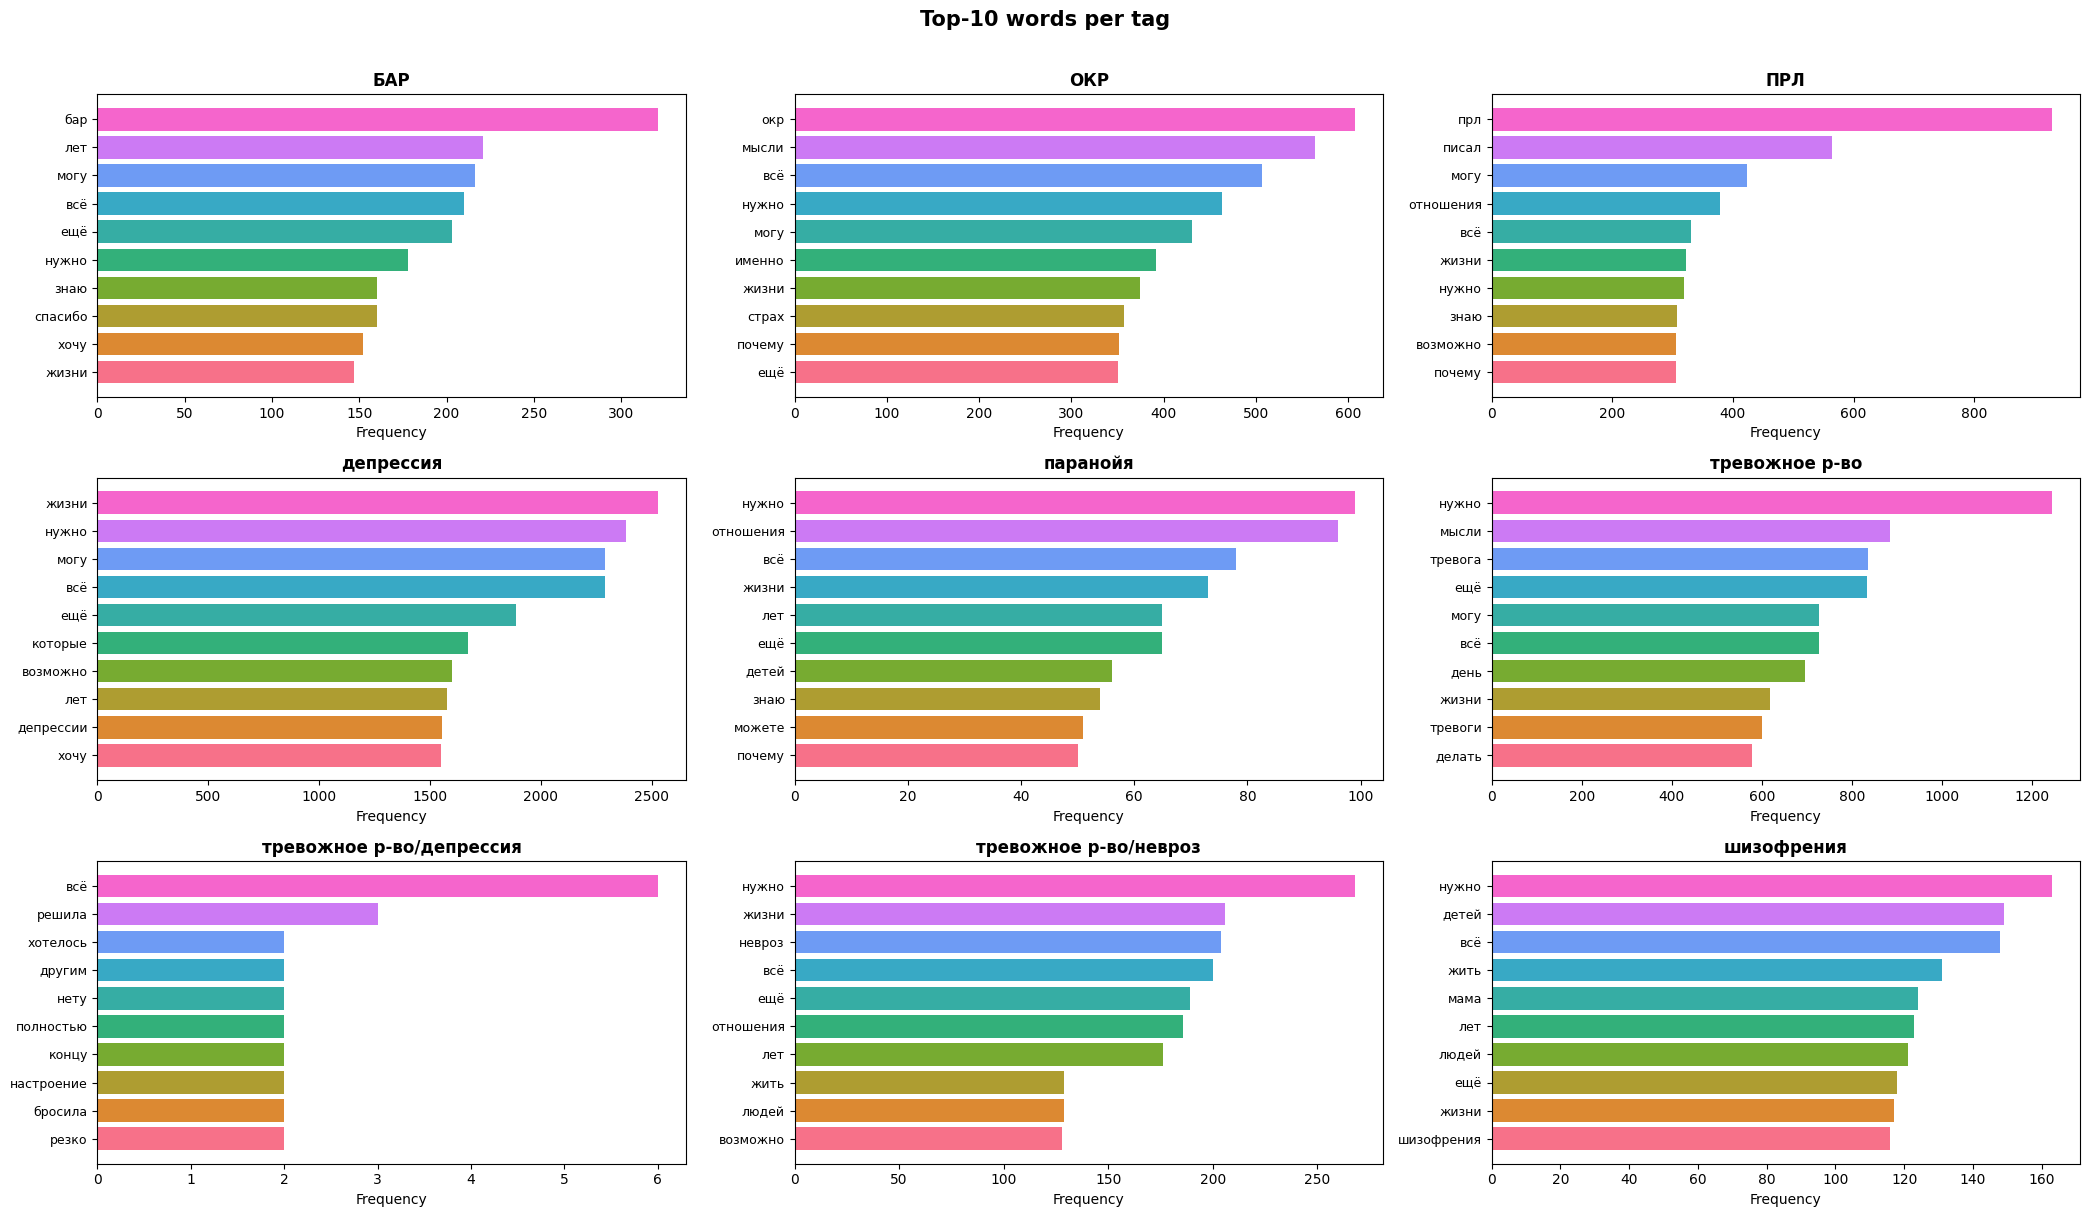

Chart saved to artifacts/data__top_words_per_tag.png


In [64]:
# Bar-chart grid: one sub-plot per tag, top-N words
tags = top_words_df['tag'].unique()
n_cols = 3
n_rows = -(-len(tags) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
axes = axes.flatten()

colors = sns.color_palette('husl', TOP_N)

for ax, tag in zip(axes, tags):
    subset = top_words_df[top_words_df['tag'] == tag].sort_values('freq')
    ax.barh(subset['word'], subset['freq'], color=colors[:len(subset)])
    ax.set_title(tag, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

# Hide any unused axes
for ax in axes[len(tags):]:
    ax.set_visible(False)

plt.suptitle(f'Top-{TOP_N} words per tag', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
out = artifact_path('top_words_per_tag.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

---
## 6. Summary

In [65]:
summary = {
    'dataset_file': DATASET_FILENAME,
    'n_samples': int(len(df)),
    'n_classes': int(df[TAG_COL].nunique()),
    'mean_chars': float(df['text_len'].mean()),
    'median_chars': float(df['text_len'].median()),
    'mean_words': float(df['word_count'].mean()),
    'median_words': float(df['word_count'].median()),
    'duplicate_texts': int(n_dup_text),
    'empty_texts': int(n_empty),
}
summary_df = pd.DataFrame(list(summary.items()), columns=['metric', 'value'])
print('=== Dataset summary ===')
print(summary_df.to_string(index=False))
summary_df.to_csv(artifact_path('summary.csv'), index=False)
print(f'\nSaved to {artifact_path("summary.csv")}')

=== Dataset summary ===
         metric       value
   dataset_file    data.csv
      n_samples       59027
      n_classes           9
     mean_chars  282.598607
   median_chars       139.0
     mean_words   43.759076
   median_words        22.0
duplicate_texts        1069
    empty_texts           0

Saved to artifacts/data__summary.csv
